<a href="https://colab.research.google.com/github/rishabh23110/videoGamesSalesAnalysis/blob/main/VideoGameAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving games.jpg to games (1).jpg


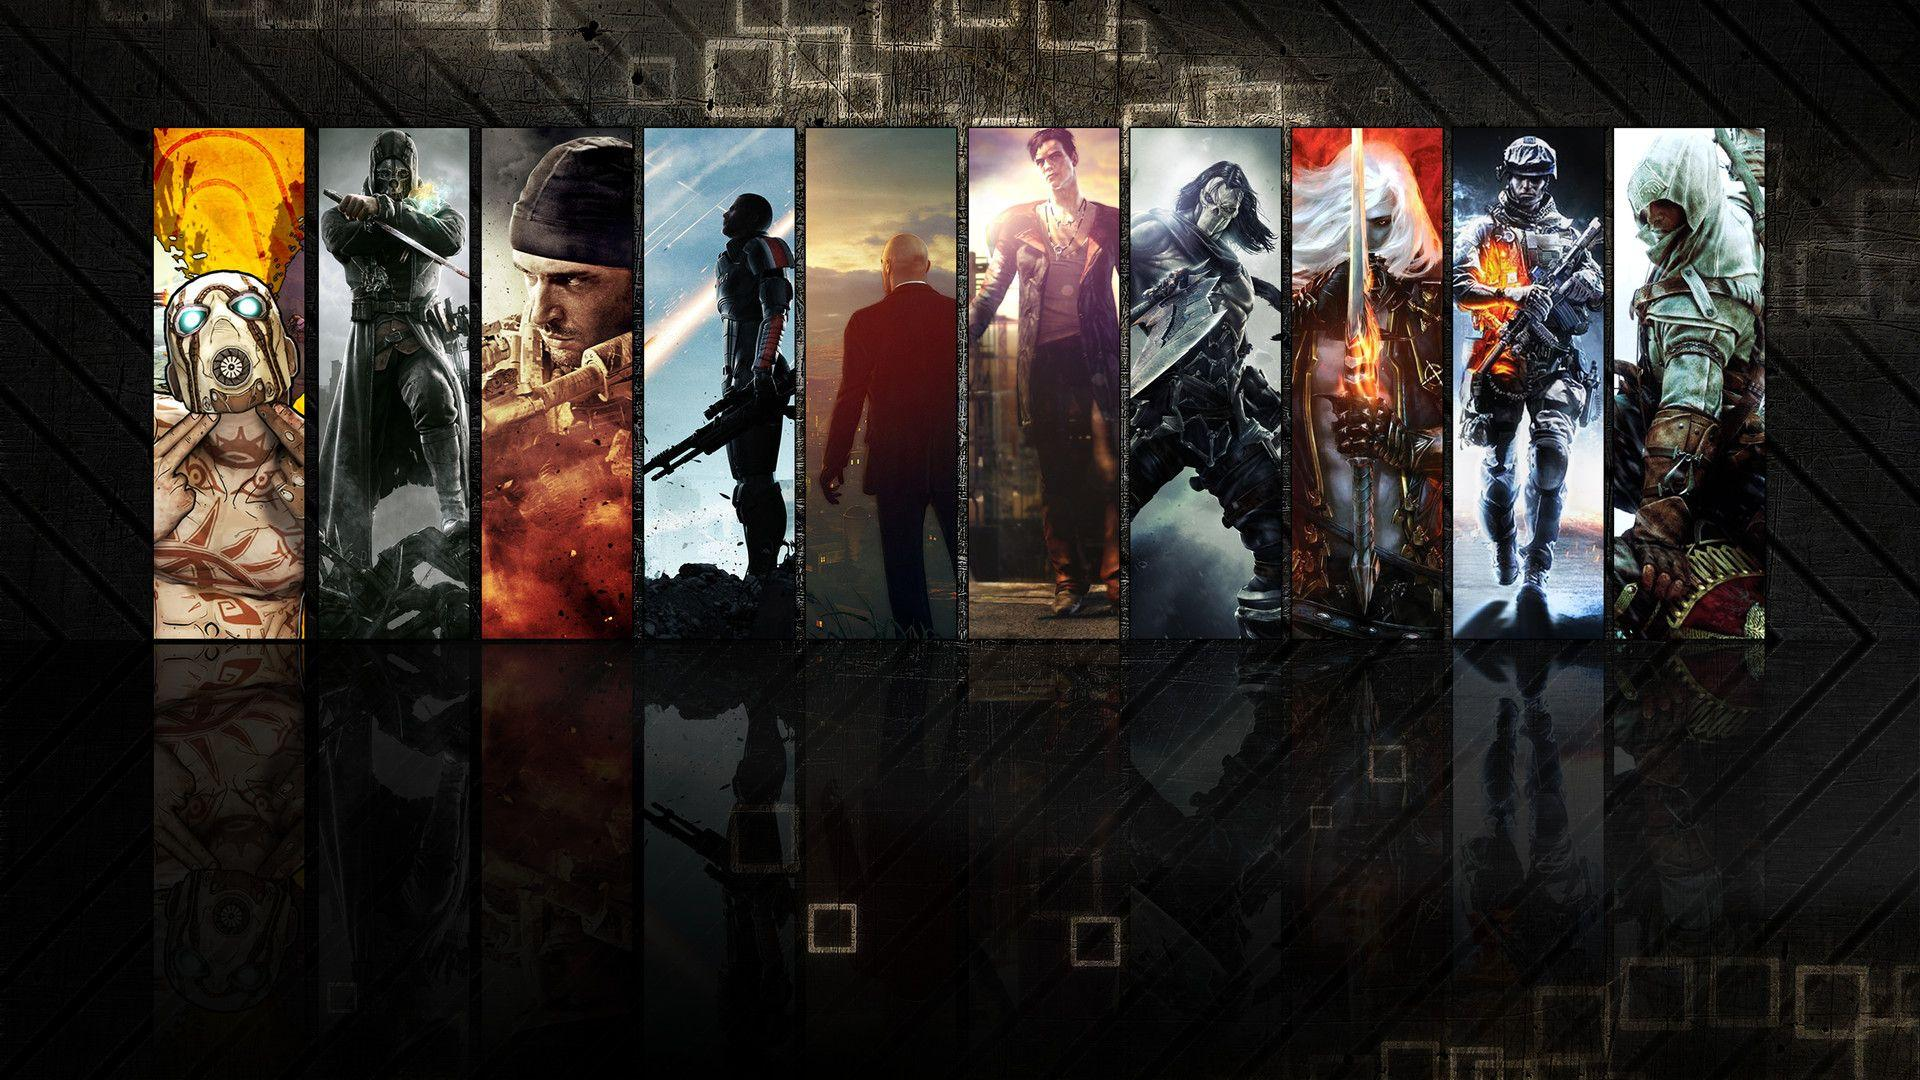

In [ ]:
from IPython.display import Image, display

display(Image('games.jpg'))

# **Data Ananlysis and Mining**


1.What the trend is video game sales (increasing or decreasing)?

2.Which genre is most lucrative in the US?

3.Which Genre has the highest sale Global?

4.Which genre is growing the fastest in sales?

5.Which genre is the highest sale in each country?

6.Top 5 platforms with highest game sales?

###**Import the required packages**

In [ ]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import plotly.graph_objs as go
import plotly.figure_factory as ff
from plotly import tools
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
init_notebook_mode(connected=True)



# Matplotlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from matplotlib.colorbar import ColorbarBase


# Others
import numpy as np
import datetime as dt
import seaborn as sns
import pickle
from math import modf

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set(style='white', context='notebook', palette='deep')

# Display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.options.display.float_format = '{:.5f}'.format

In [ ]:
plt.style.use('bmh')
params = {'legend.fontsize': '16',
          'figure.figsize': (15, 5),
         'axes.labelsize': '20',
         'axes.titlesize':'30',
         'xtick.labelsize':'18',
         'ytick.labelsize':'18'}
plt.rcParams.update(params)

plt.rcParams['text.color'] = '#A04000'
plt.rcParams['xtick.color'] = '#283747'
plt.rcParams['ytick.color'] = '#808000'
plt.rcParams['axes.labelcolor'] = '#283747'

### **Read the data**

In [ ]:
data_df = pd.read_csv("/content/vgames.csv")

In [ ]:
print("Dataset -  rows:",data_df.shape[0]," columns:", data_df.shape[1])

Dataset -  rows: 16598  columns: 11


In [ ]:
print("Number of Duplicates enteries : ", data_df.duplicated().sum())

Number of Duplicates enteries :  0


***There are no duplicates in the dataset.***

In [ ]:
pd.DataFrame(data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   US_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


""


In [ ]:
data_df.describe()

,Rank,Year,US_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.00000,16327.00000,16598.00000,16598.00000,16598.00000,16598.00000,16598.00000
mean,8300.60525,2006.40644,0.26467,0.14665,0.07778,0.04806,0.53744
std,4791.85393,5.82898,0.81668,0.50535,0.30929,0.18859,1.55503
min,1.00000,1980.00000,0.00000,0.00000,0.00000,0.00000,0.01000
25%,4151.25000,2003.00000,0.00000,0.00000,0.00000,0.00000,0.06000
50%,8300.50000,2007.00000,0.08000,0.02000,0.00000,0.01000,0.17000
75%,12449.75000,2010.00000,0.24000,0.11000,0.04000,0.04000,0.47000
max,16600.00000,2020.00000,41.49000,29.02000,10.22000,10.57000,82.74000


In [ ]:
data_df.head()

,Rank,Name,Platform,Year,Genre,Publisher,US_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.00000,Sports,Nintendo,41.49000,29.02000,3.77000,8.46000,82.74000
1,2,Super Mario Bros.,NES,1985.00000,Platform,Nintendo,29.08000,3.58000,6.81000,0.77000,40.24000
2,3,Mario Kart Wii,Wii,2008.00000,Racing,Nintendo,15.85000,12.88000,3.79000,3.31000,35.82000
3,4,Wii Sports Resort,Wii,2009.00000,Sports,Nintendo,15.75000,11.01000,3.28000,2.96000,33.00000
4,5,Pokemon Red/Pokemon Blue,GB,1996.00000,Role-Playing,Nintendo,11.27000,8.89000,10.22000,1.00000,31.37000


In [ ]:
df = data_df.copy()
df['Year'] = pd.to_datetime(df.Year, format='%Y')
df = df.sort_values(by = 'Year')
df = df.reset_index(drop = True)
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,US_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,6898,Checkers,2600,1980-01-01,Misc,Atari,0.22000,0.01000,0.00000,0.00000,0.24000
1,2671,Boxing,2600,1980-01-01,Fighting,Activision,0.72000,0.04000,0.00000,0.01000,0.77000
2,5368,Freeway,2600,1980-01-01,Action,Activision,0.32000,0.02000,0.00000,0.00000,0.34000
3,1971,Defender,2600,1980-01-01,Misc,Atari,0.99000,0.05000,0.00000,0.01000,1.05000
4,1768,Kaboom!,2600,1980-01-01,Misc,Activision,1.07000,0.07000,0.00000,0.01000,1.15000


## **1. What the trend is video game sales (increasing or decreasing)?**

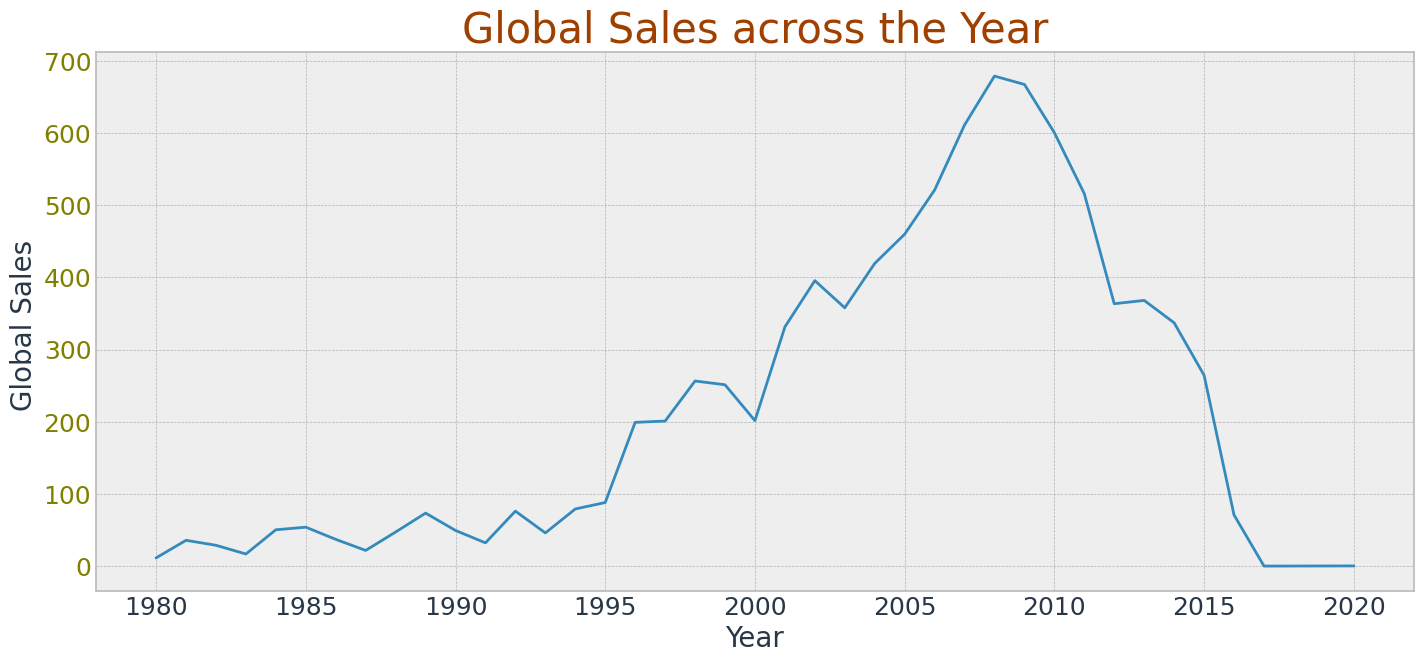

In [ ]:
sales_trend = df.groupby([df['Year'].dt.date])['Global_Sales'].sum()
sales_trend.plot(kind = 'line', figsize = (17,7))
plt.title('Global Sales across the Year')
plt.xlabel('Year')
plt.ylabel('Global Sales ')
plt.show()

***The Sales increased from 1980 to 2007, then has significantly dropped from 2008 to 2020.***

## **2. Which genre is most lucrative in the US?**

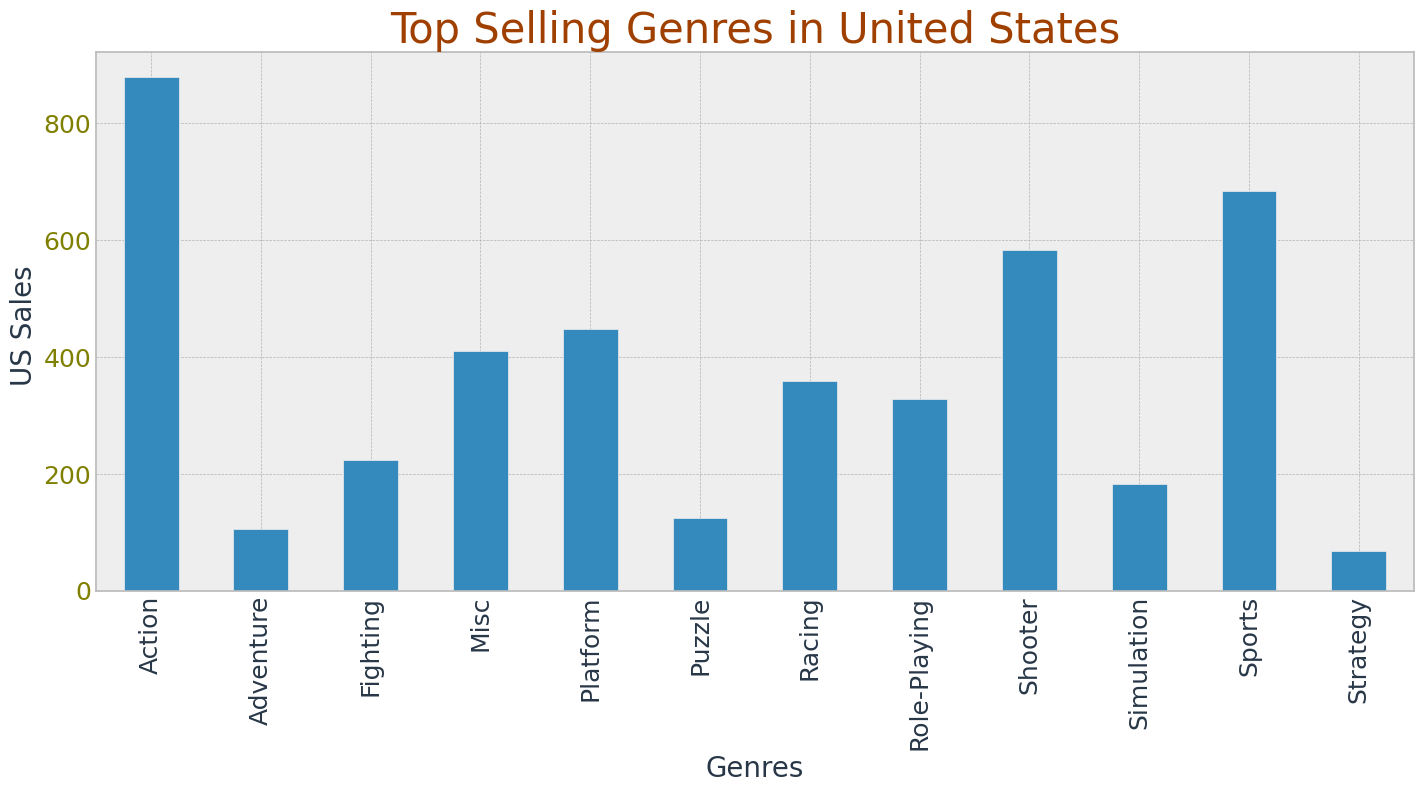

In [ ]:
US_genres = df.groupby([df['Genre']])['US_Sales'].sum()
US_genres.plot(kind = 'bar', figsize = (17,7))
plt.title('Top Selling Genres in United States')
plt.xlabel('Genres')
plt.ylabel('US Sales ')
plt.show()

***Action is most lucrative Genre in the US.***

## **3. Which Genre has the highest sale Global?**

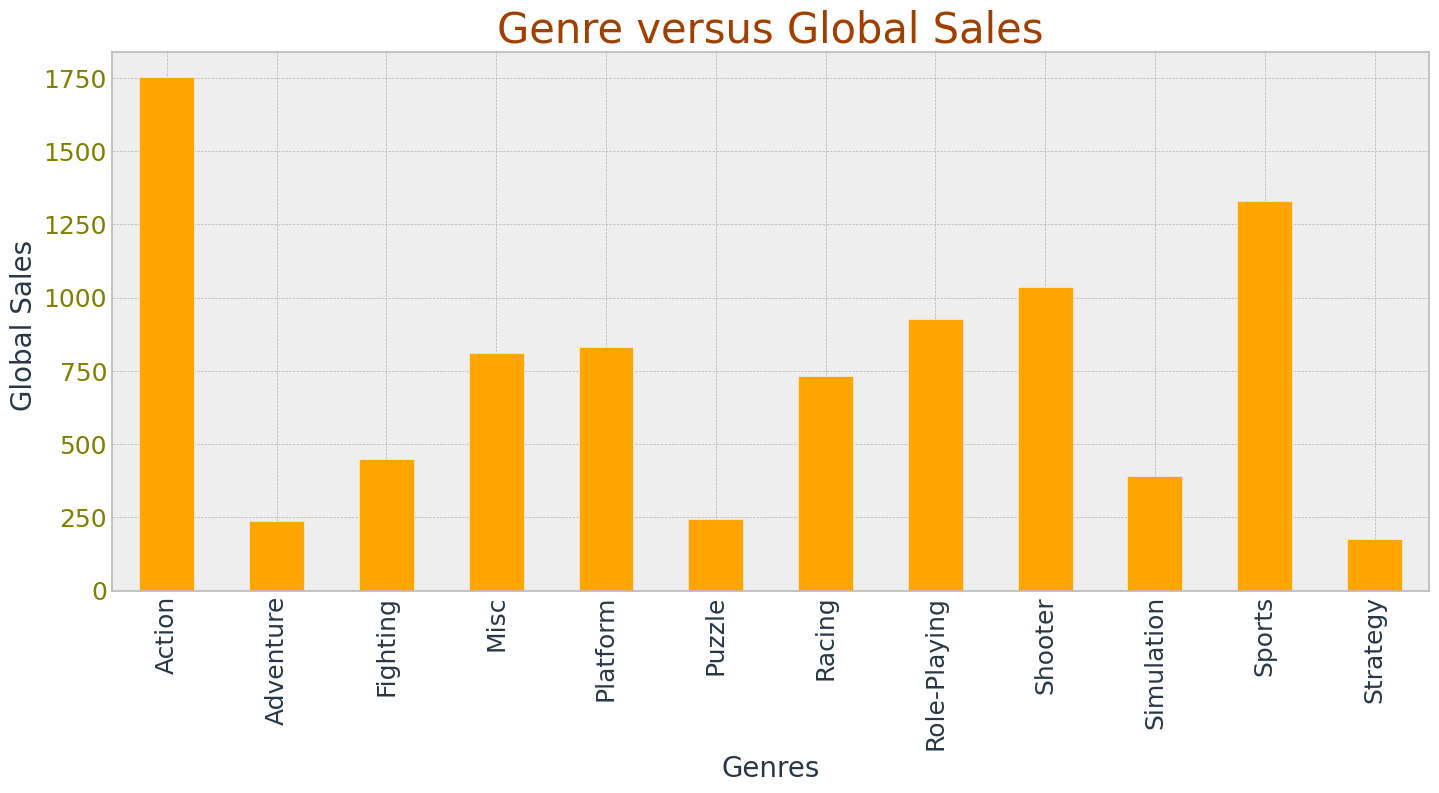

In [ ]:
global_sales = df.groupby([df['Genre']])['Global_Sales'].sum()
global_sales.plot(kind = 'bar', figsize = (17,7), color = 'orange')
plt.title('Genre versus Global Sales')
plt.xlabel('Genres')
plt.ylabel('Global Sales ')
plt.show()

***Action Genre has the highest sale in Global.***

##  **4. Which genre is growing the fastest in sales?**

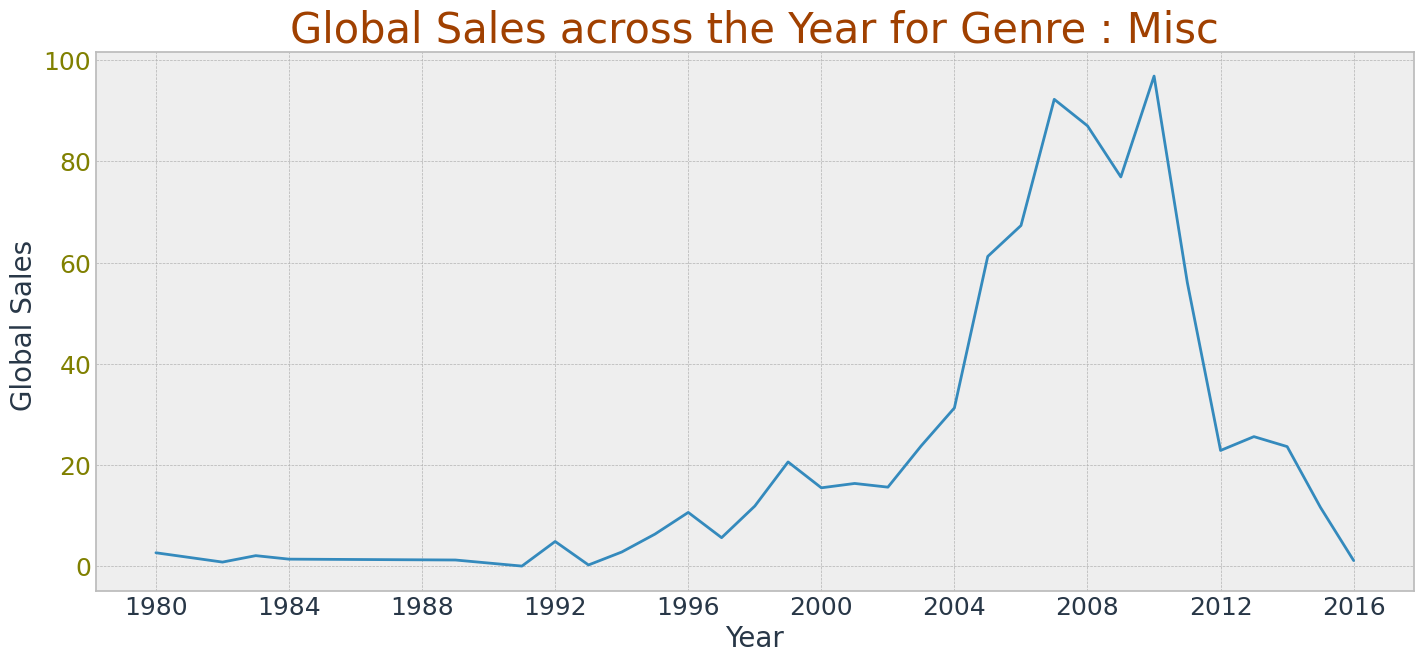

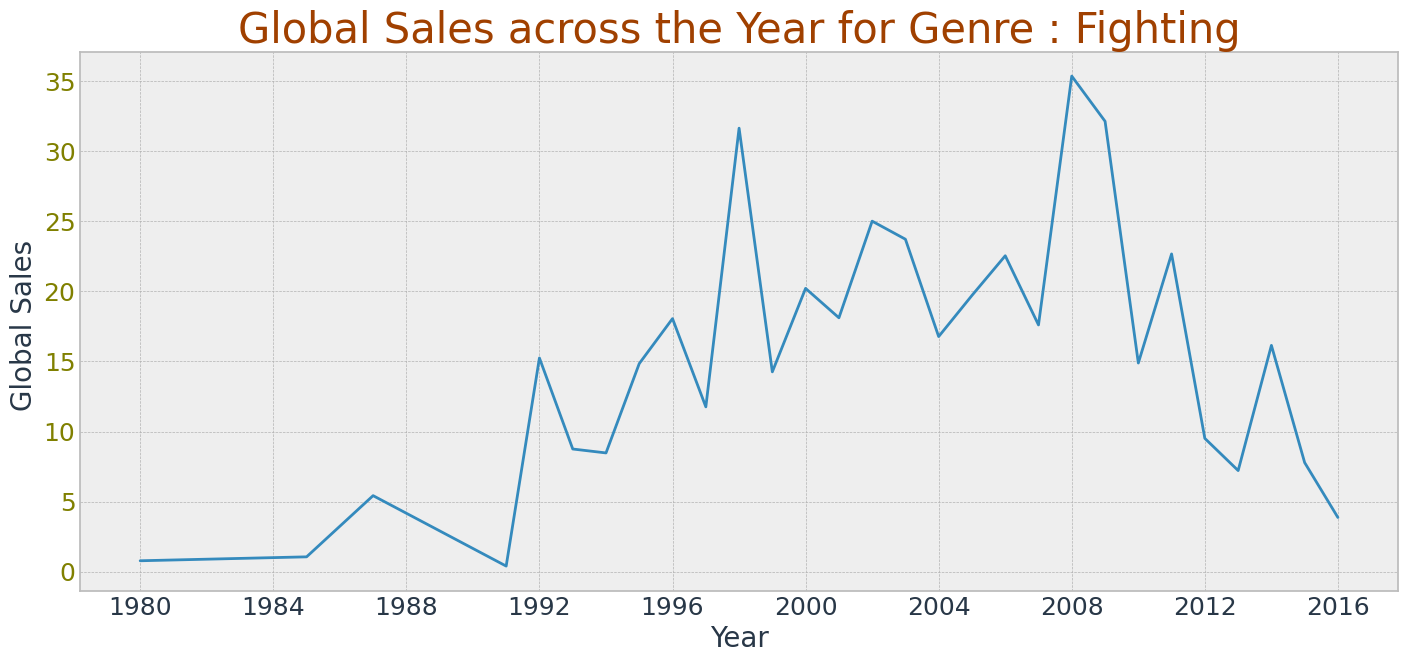

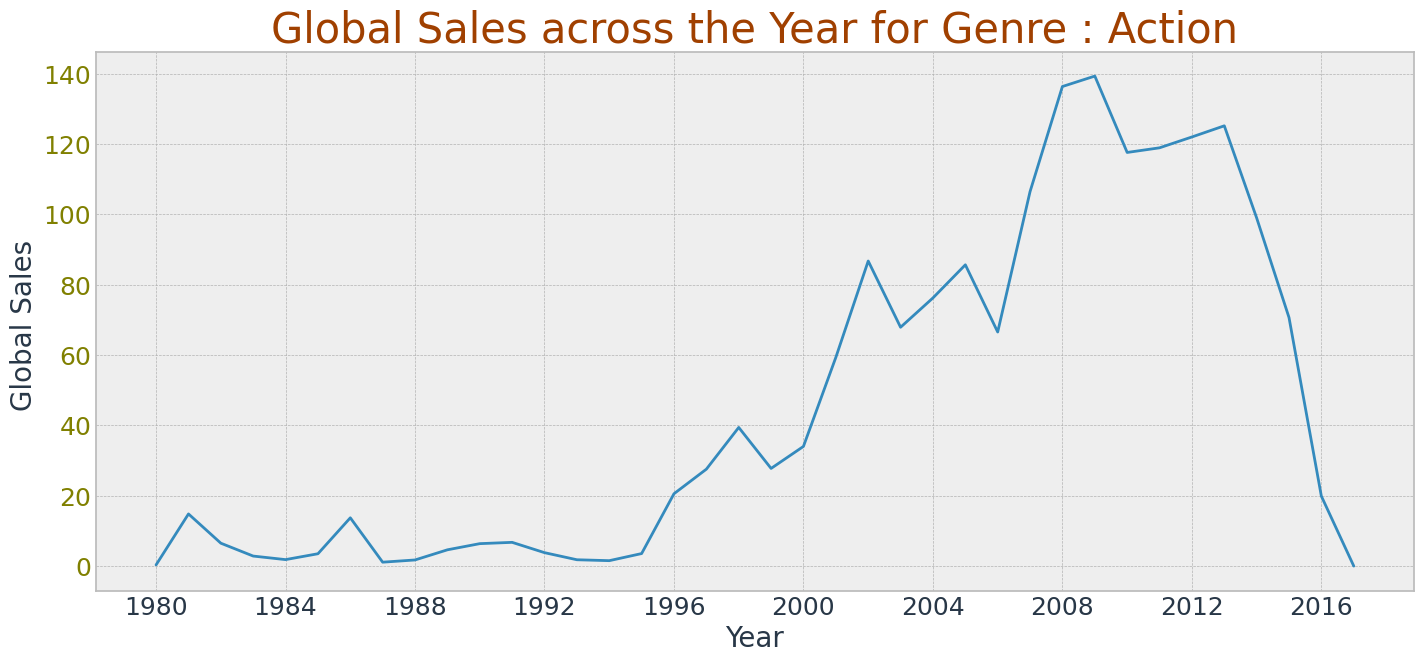

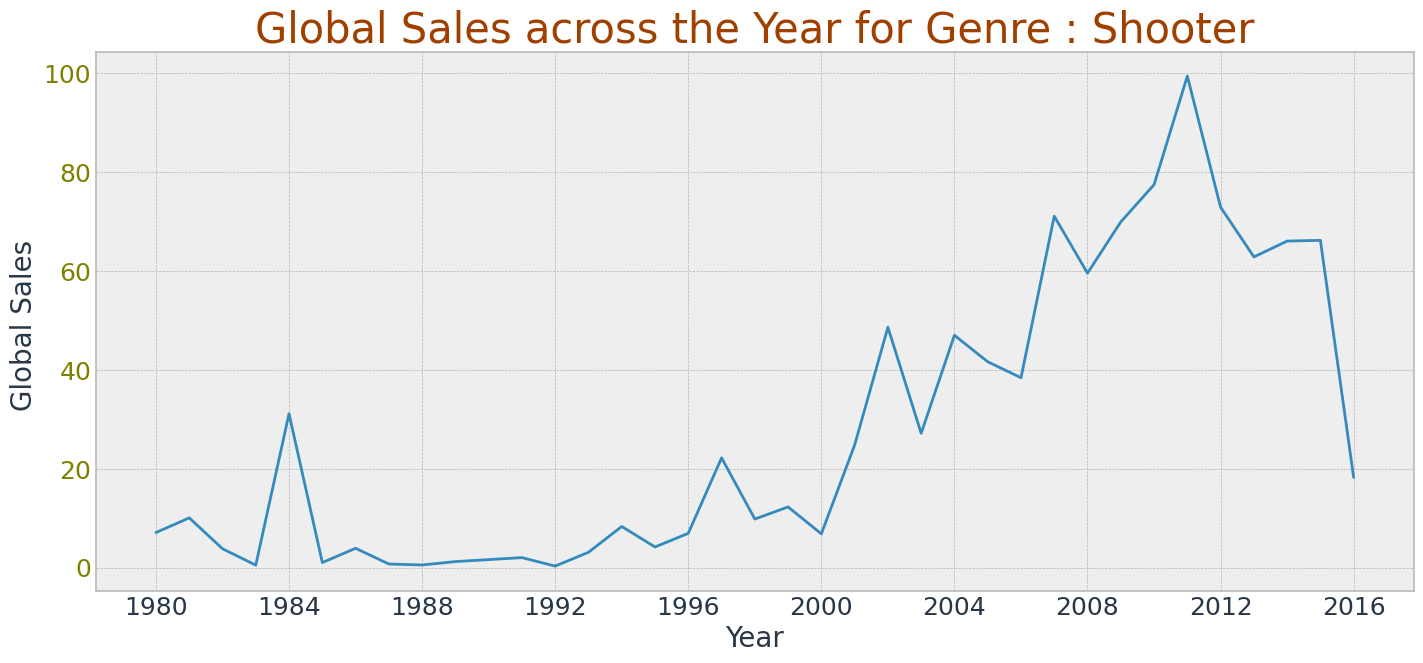

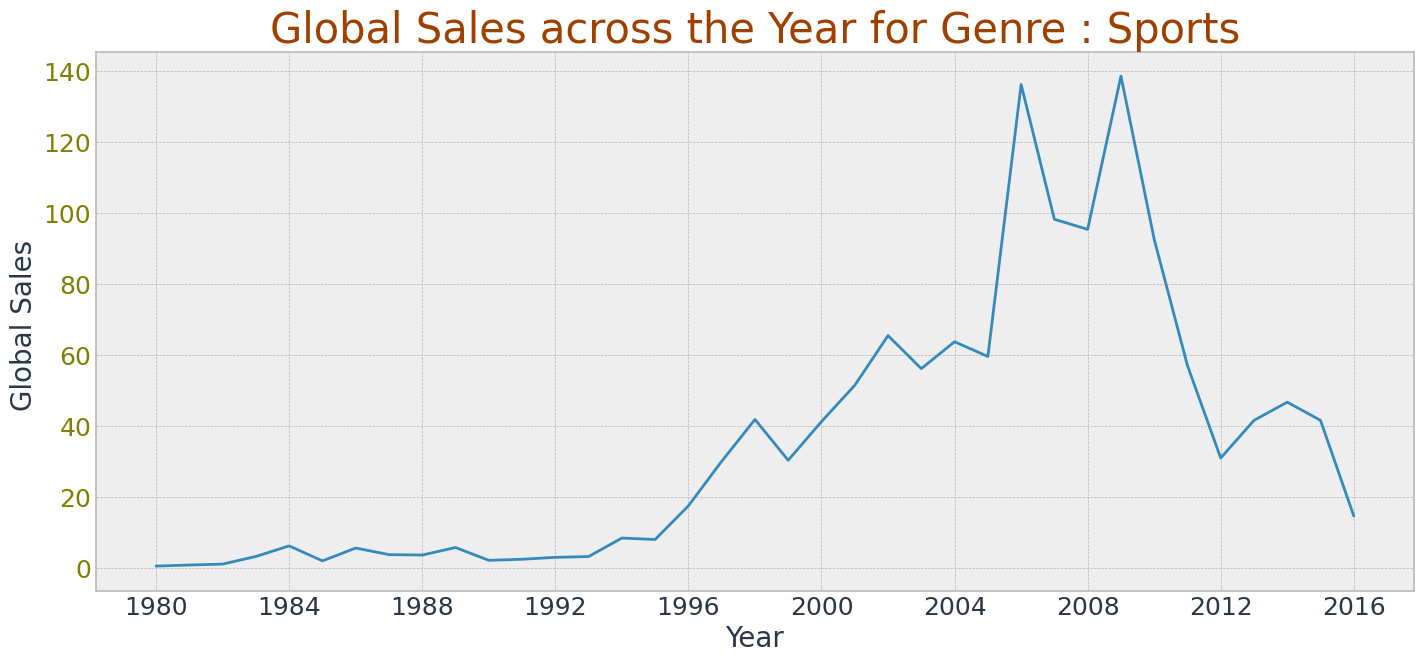

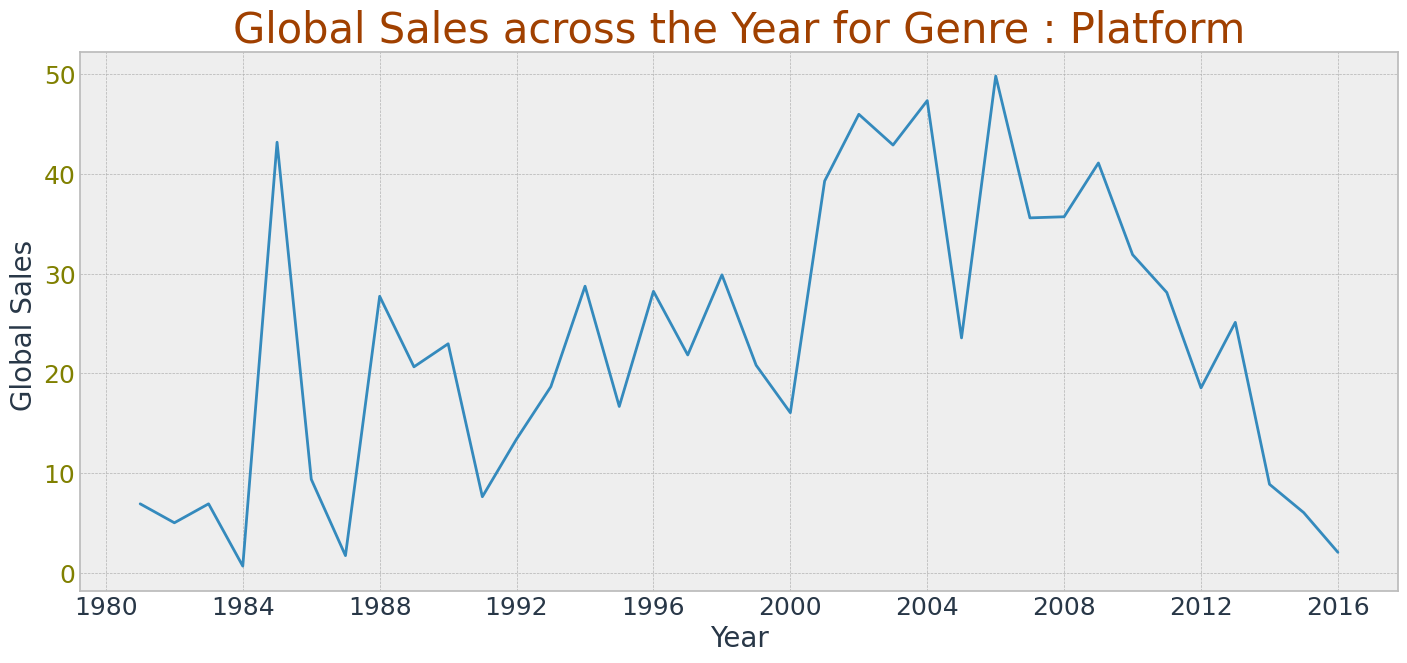

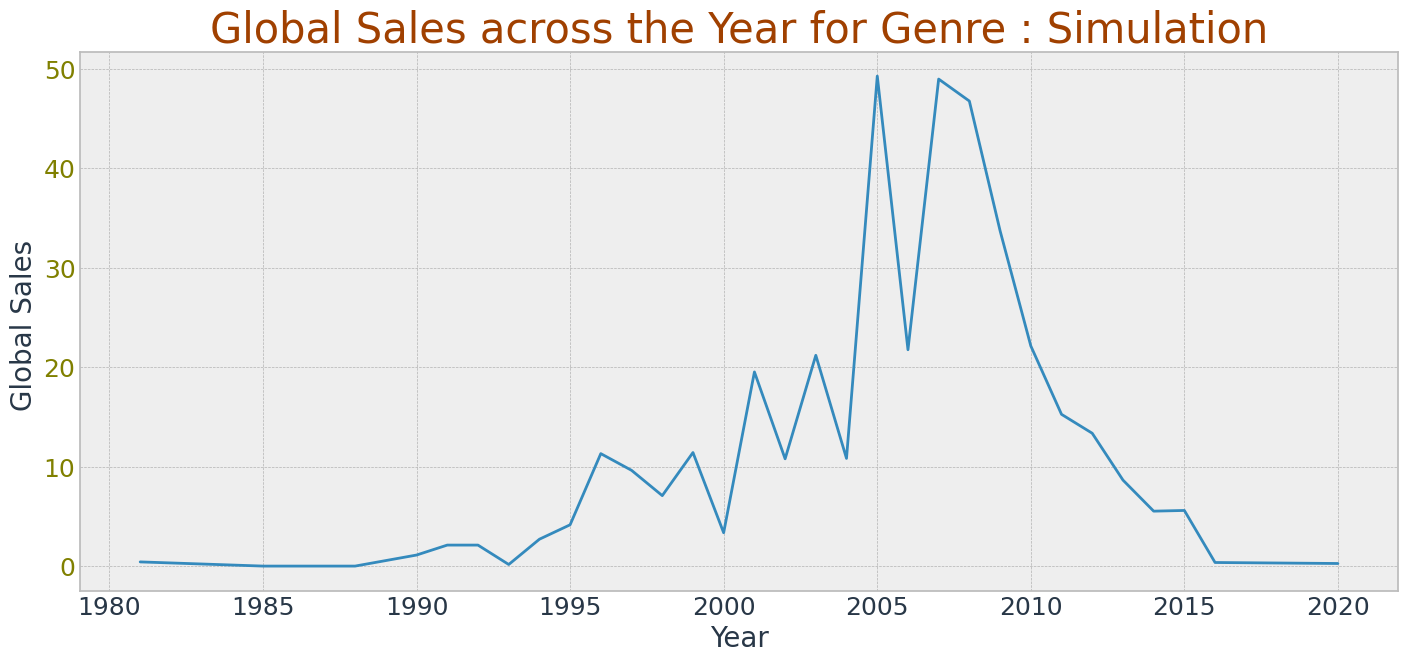

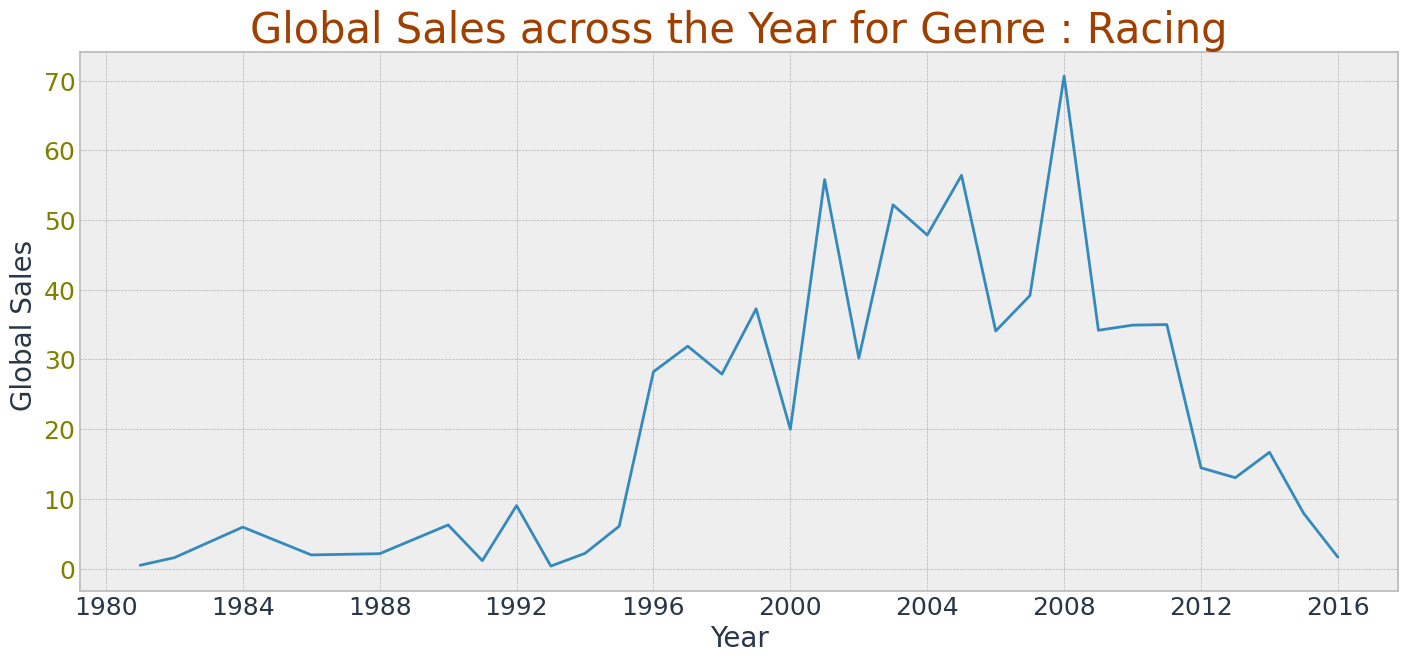

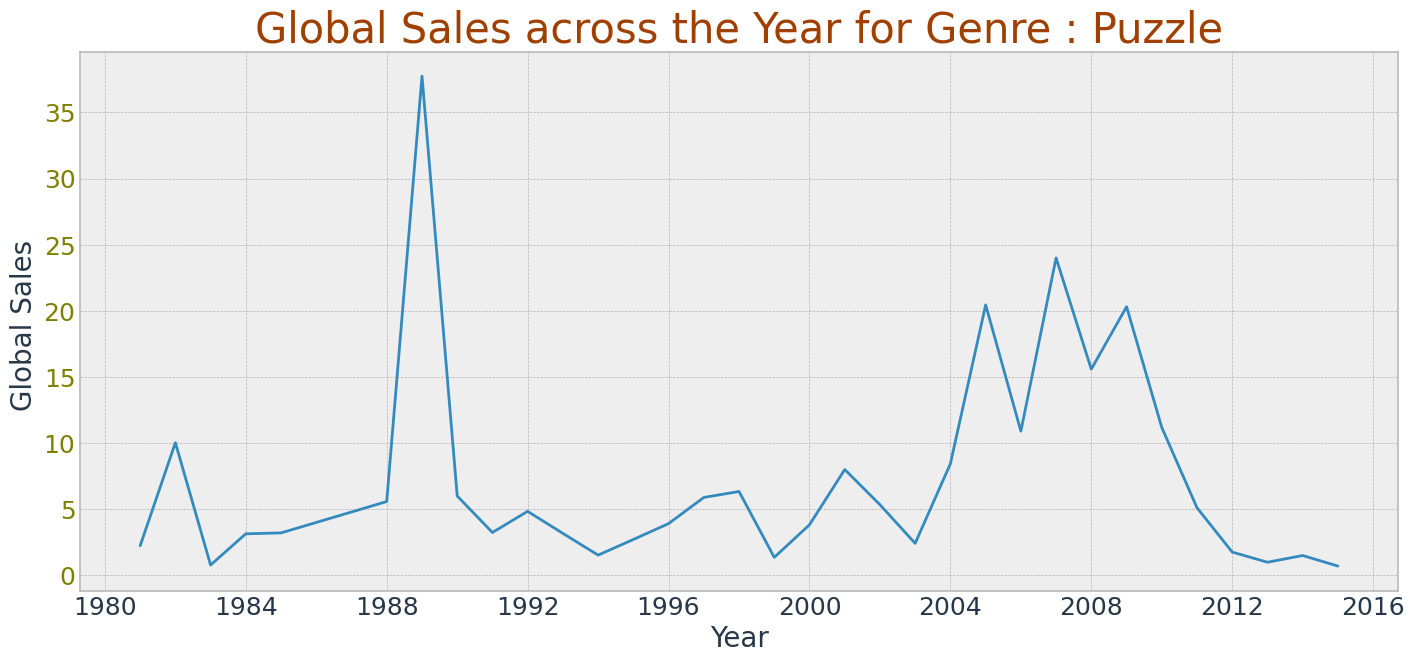

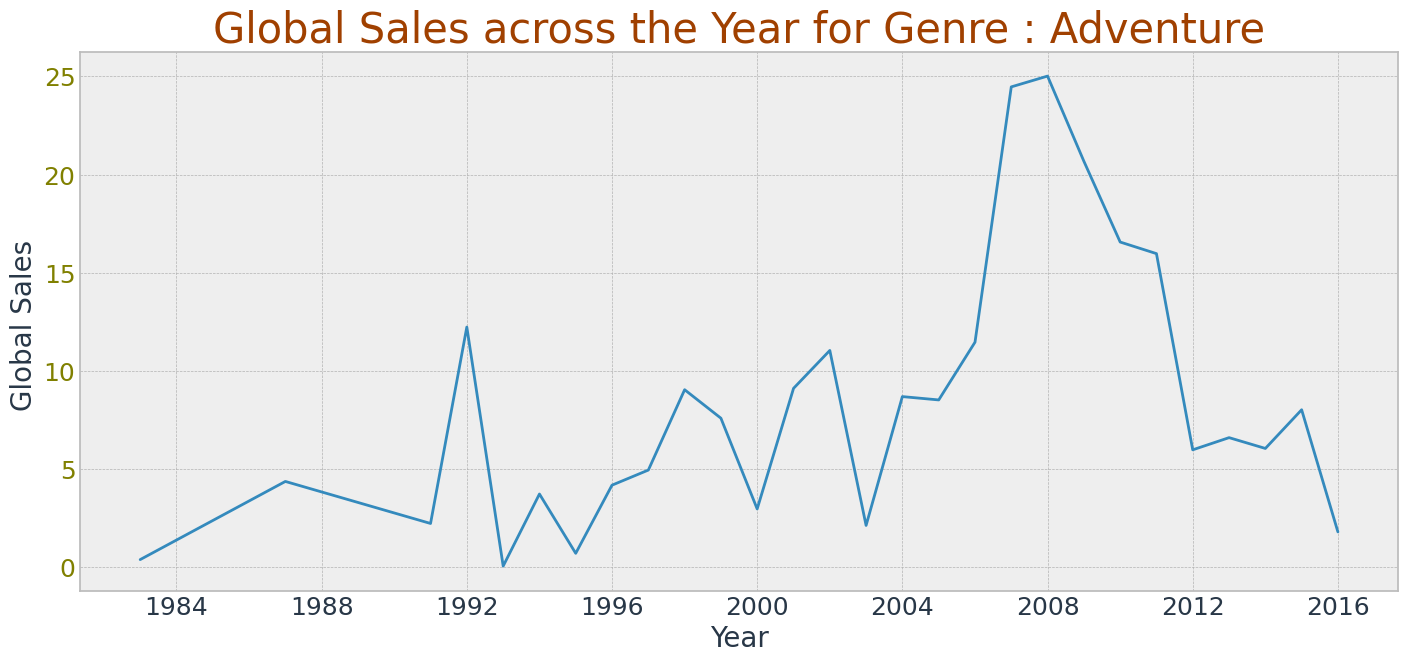

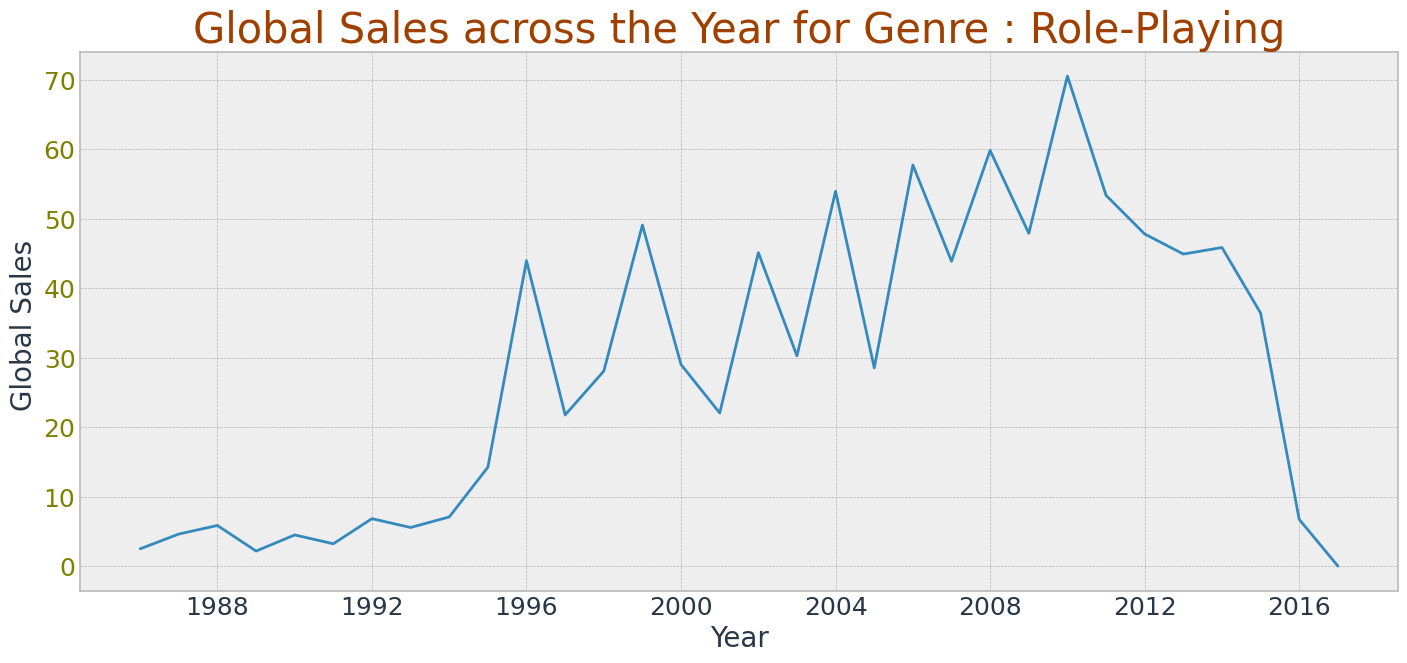

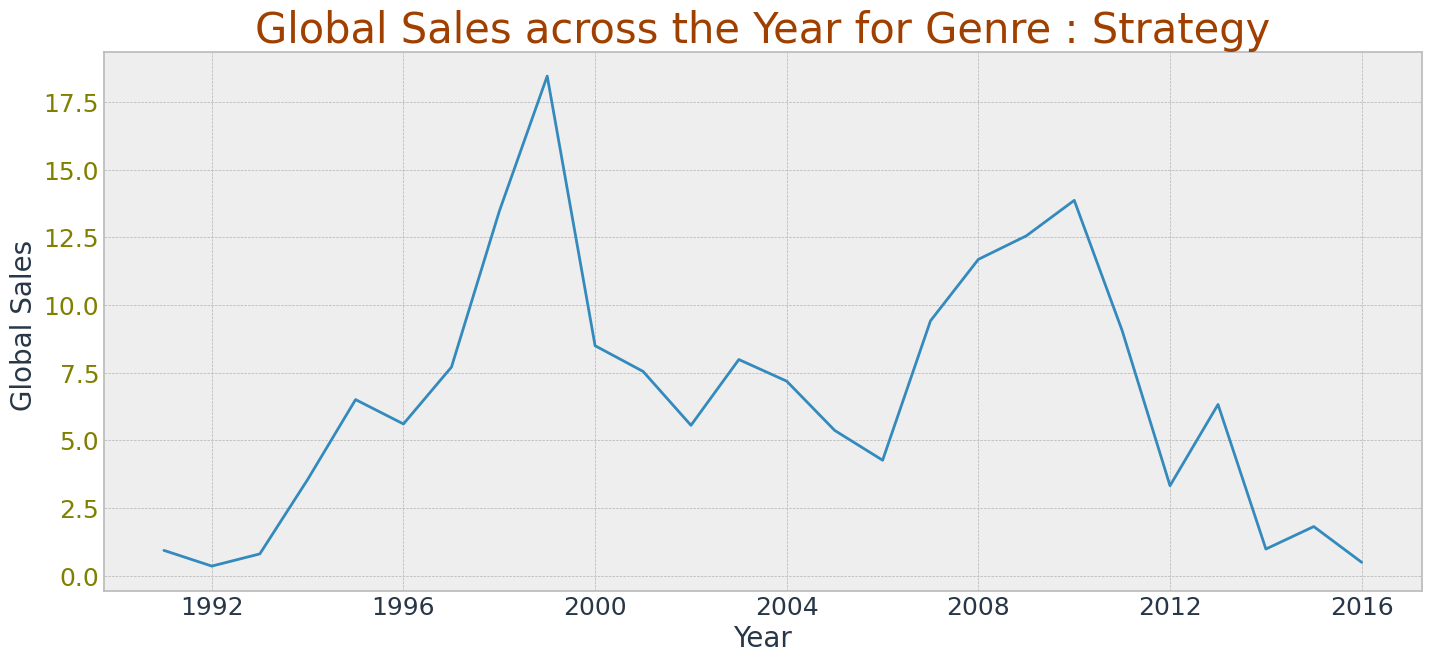

In [ ]:
genres = df['Genre'].unique().tolist()

for genre in genres:
    dfs = df[df['Genre'] == genre]
    sales_trend = dfs.groupby([dfs['Year'].dt.date])['Global_Sales'].sum()
    sales_trend.plot(kind = 'line', figsize = (17,7))
    plt.title('Global Sales across the Year for Genre : ' + genre)
    plt.xlabel('Year')
    plt.ylabel('Global Sales ')
    plt.show();

***Sports is fastest growning Genre glabally.***

## **5.Which genre is the highest sale in each country?**

In [ ]:
pd.DataFrame(
    df.groupby('Genre')[['US_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
)

,US_Sales,EU_Sales,JP_Sales,Other_Sales
Genre,,,,
Action,877.83000,525.00000,159.95000,187.38000
Adventure,105.80000,64.13000,52.07000,16.81000
Fighting,223.59000,101.32000,87.35000,36.68000
Misc,410.24000,215.98000,107.76000,75.32000
Platform,447.05000,201.63000,130.77000,51.59000
Puzzle,123.78000,50.78000,57.31000,12.55000
Racing,359.42000,238.39000,56.69000,77.27000
Role-Playing,327.28000,188.06000,352.31000,59.61000
Shooter,582.60000,313.27000,38.28000,102.69000


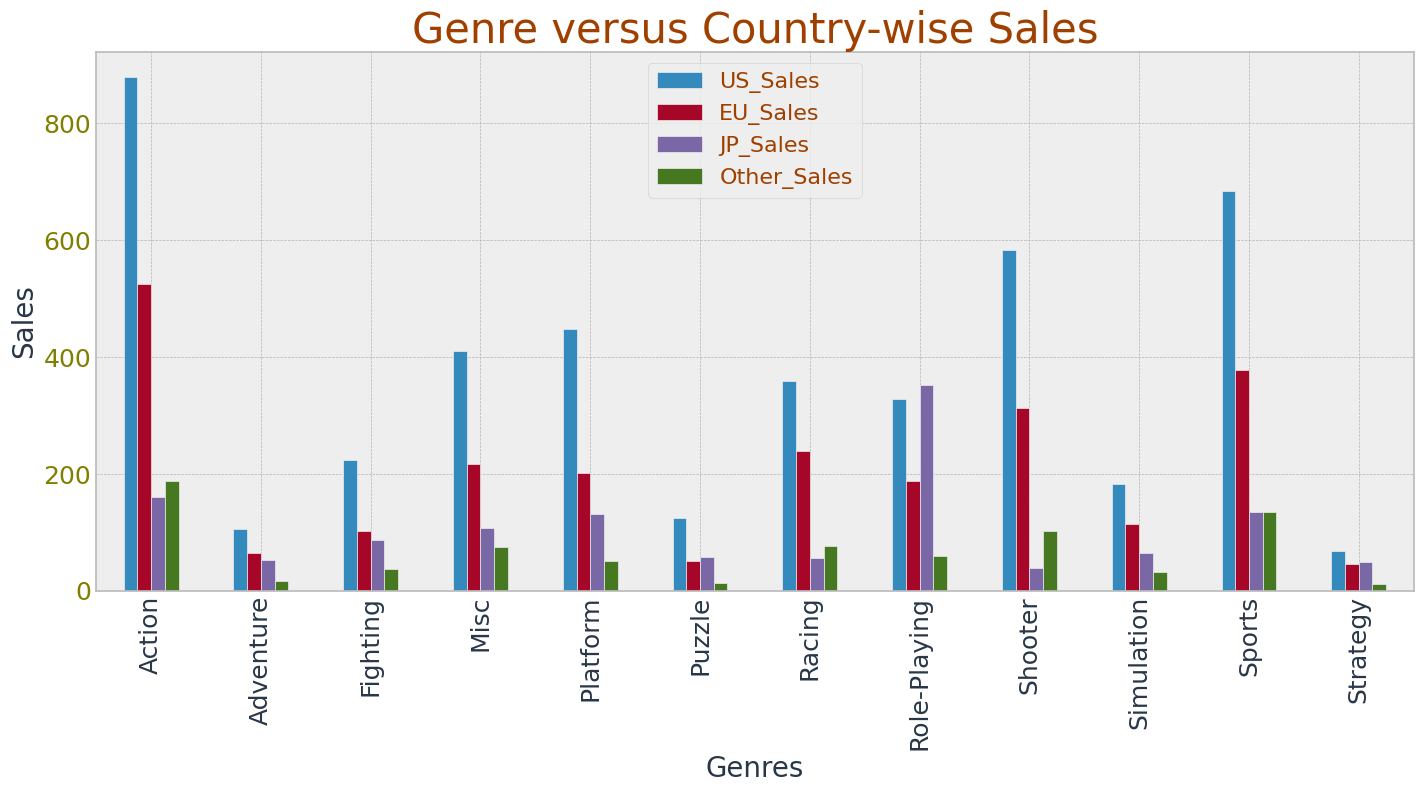

In [ ]:
df.groupby('Genre')[['US_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']] \
  .sum() \
  .plot(kind='bar', figsize=(17,7))

plt.title('Genre versus Country-wise Sales')
plt.xlabel('Genres')
plt.ylabel('Sales')
plt.show()

***Action genre is the highest sale in each country.***

## **6. Top 5 platforms with highest game sales?**

In [ ]:
pd.DataFrame(df.groupby([df['Platform']])['Global_Sales'].sum().sort_values(ascending  = False))

,Global_Sales
Platform,
PS2,1255.64000
X360,979.96000
PS3,957.84000
Wii,926.71000
DS,822.49000
PS,730.66000
GBA,318.50000
PSP,296.28000
PS4,278.10000


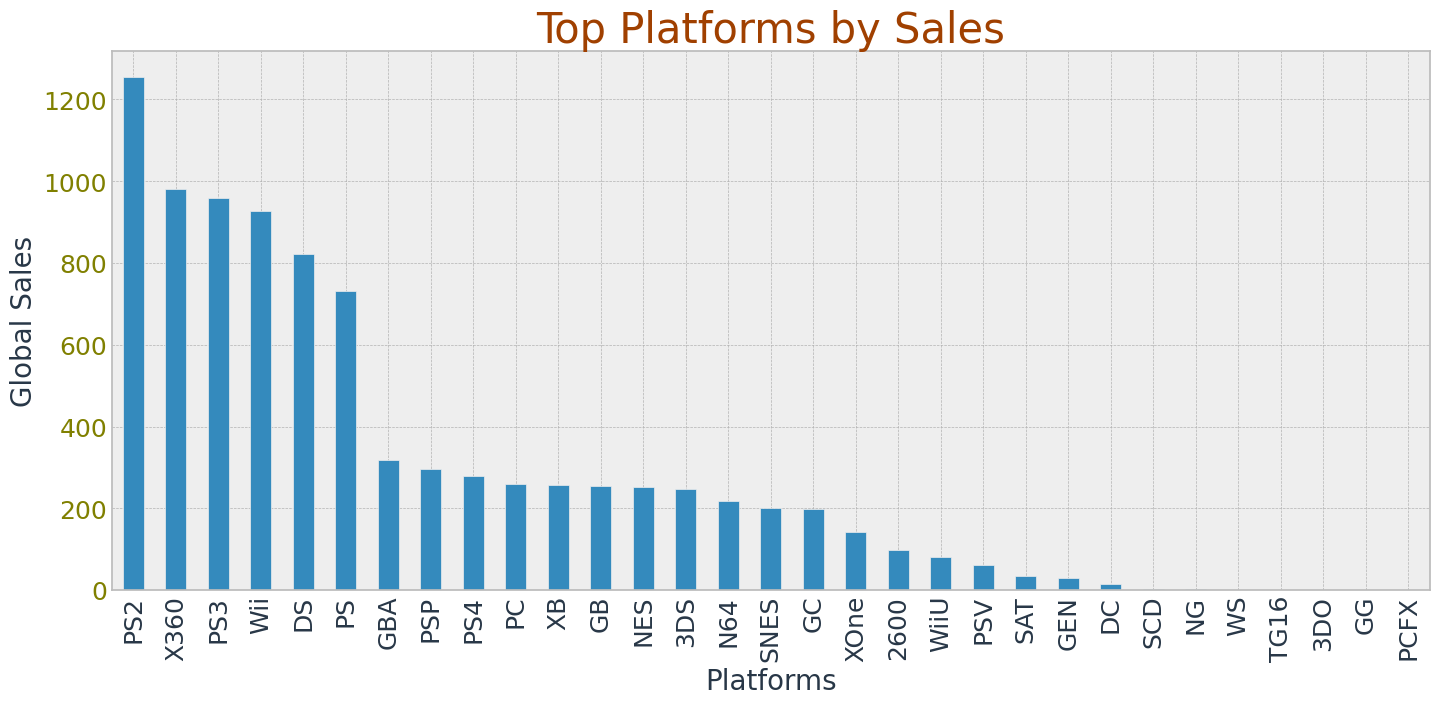

In [ ]:
df.groupby([df['Platform']])['Global_Sales'].sum().sort_values(ascending  = False).plot(kind = 'bar', figsize = (17,7))
plt.title('Top Platforms by Sales')
plt.xlabel('Platforms')
plt.ylabel('Global Sales')
plt.show();

***PS2, X360, PS3, Wii and DS are the top 5 platforms of all time by the Sales.***